# Q3: Four Rooms Again

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import random

"""DO NOT CHANGE"""
class FourRooms(object):
    def __init__(self):
        # define the four room as a 2-D array for easy state space reference and visualization
        # 0 represents an empty cell; 1 represents a wall cell
        self.four_room_space = np.array([[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
                                         [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
                                         [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                                         [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
                                         [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
                                         [1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0],
                                         [0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1],
                                         [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
                                         [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
                                         [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                                         [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]])

        # find the positions for all empty cells
        # note that: the origin for a 2-D numpy array is located at top-left while the origin for the FourRooms is at
        # the bottom-left. The following codes performs the re-projection.
        empty_cells = np.where(self.four_room_space == 0.0)
        self.state_space = [[col, 10 - row] for row, col in zip(empty_cells[0], empty_cells[1])]

        # define the action space
        self.action_space = {'LEFT': np.array([-1, 0]),
                             'RIGHT': np.array([1, 0]),
                             'DOWN': np.array([0, -1]),
                             'UP': np.array([0, 1])}

        # define the start state
        self.start_state = [0, 0]

        # define the goal state
        self.goal_state = [10, 10]

        # maximal time steps
        self.max_time_steps = 459

        # track the time step
        self.t = 0

    def reset(self):
        """
        Reset the agent's state to the start state [0, 0]
        Return both the start state and reward
        """
        # reset the agent state to be [0, 0]
        state = self.start_state
        # reset the reward to be 0
        reward = 0
        # reset the termination flag
        done = False
        # reset the time step tracker
        self.t = 0
        return state, reward, done

    def step(self, state, act):
        """
        Args:
            state: a list variable containing x, y integer coordinates. (i.e., [1, 1]).
            act: a string variable (i.e., "UP"). All feasible values are ["UP", "DOWN", "LEFT", "RIGHT"].
        Output args:
            next_state: a list variable containing x, y integer coordinates (i.e., [1, 1])
            reward: an integer. it can be either 0 or 1.
        """
        # Increase the time step
        self.t += 1

        # With probability 0.8, the agent takes the correct direction.
        # With probability 0.2, the agent takes one of the two perpendicular actions.
        # For example, if the correct action is "LEFT", then
        #     - With probability 0.8, the agent takes action "LEFT";
        #     - With probability 0.1, the agent takes action "UP";
        #     - With probability 0.1, the agent takes action "DOWN".
        if np.random.uniform() < 0.2:
            if act == "LEFT" or act == "RIGHT":
                act = np.random.choice(["UP", "DOWN"], 1)[0]
            else:
                act = np.random.choice(["RIGHT", "LEFT"], 1)[0]

        # Compute the next state
        next_state = self.take_action(state, act)

        # Compute the reward
        reward = 1.0 if next_state == [10, 10] else 0.0

        # Check the termination
        # If the agent reaches the goal, reward = 1, done = True
        # If the time steps reaches the maximal number, reward = 0, done = True.
        if next_state == [10, 10] or self.t == self.max_time_steps:
            done = True
        else:
            done = False

        return next_state, reward, done

    def take_action(self, state, act):
        """
        Input args:
            state (list): a list variable containing x, y integer coordinates. (i.e., [1, 1]).
            act (string): a string variable (i.e., "UP"). All feasible values are ["UP", "DOWN", "LEFT", "RIGHT"].
        Output args:
            next_state (list): a list variable containing x, y integer coordinates (i.e., [1, 1])
        """
        state = np.array(state)
        next_state = state + self.action_space[act]
        return next_state.tolist() if next_state.tolist() in self.state_space else state.tolist()

# a.) Implement semi-gradient one-step SARSA using the following state aggregation
* Each state is only aggregated to itself. In other words, the aggregated state space is identical to the original state space.
* Since we use SARSA and want to learn Q values, we design the feature for each state(aggregated)-
action pair using one-hot encoding. For example, if the size of the aggregate state space is N and the size of the action space is M , then given a state(aggregated)-action pair, you should represent it as a one-hot encoding vector f = [0, 1, 0, .., 0]d, where d = N ×M .
* Given the one-hot vector as the feature for each state(aggregated)-action pair, the weights are defined as a vector w = [w0, w1, w2, ..., wd], where d = N ×M .
* Following such design, we can approximate the Q value for one state(aggregated)-action pair as
Q(s, a) = wT f (s, a) = wi, where f (s, a) is the one-hot vector and i is the index of the state(aggregated)-action pair. Obviously, each element in w corresponds to the Q value of one state(aggregated)-action pair. We can call this strategy a tabular state aggregation.

In [13]:
class SemiGradient_SARSA:
    def __init__(self, env, gamma, alpha, epsilon):
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.env = env

        self.state_num = len(self.env.state_space)
        self.action_num = len(self.env.action_space.keys())
        self.weight = np.random.uniform(-0.01, 0.01, self.state_num * self.action_num)
        
    def feature(self, s, a):
        f = np.zeros(self.state_num * self.action_num)
        f[s * self.action_num + a] = 1
        return f

    def q_hat(self, s, a):
        q_hat = np.dot(self.weight, self.feature(s, a))
        return q_hat

    def behavior_policy(self, s):
        if np.random.random() < self.epsilon:
            return np.random.randint(self.action_num)
        else:
            return np.argmax([self.q_hat(s, a) for a in range(self.action_num)])

    def terminal(self, r, s, a):
        self.weight = self.weight + self.alpha * (r - self.q_hat(s, a)) * self.feature(s, a)
    
    def update(self, r, a, s, a_prime, s_prime):
        self.weight = self.weight + self.alpha * (r + self.gamma * self.q_hat(s_prime, a_prime) - self.q_hat(s, a)) * self.feature(s, a)

    def rollout(self):
        state, reward, terminated = self.env.reset()
        state = self.env.state_space.index(state)
        actions = list(self.env.action_space.keys())
        action = self.behavior_policy(state)
        t = 0
        while not terminated:
            s_prime, reward, terminated = self.env.step(self.env.state_space[state], actions[action])
            s_prime = self.env.state_space.index(s_prime)
            if terminated:
                self.terminal(reward, state, action)
            else:
                a_prime = self.behavior_policy(s_prime)
                self.update(reward, action, state, a_prime, s_prime)
                state = s_prime
                action = a_prime
            t += 1
        return t

    def run(self):
        steps = []
        total_steps = 0
        for ep in range(100):  # more episodes to allow learning
            t = self.rollout()
            total_steps += t
            steps.append(total_steps)
        return steps

In [20]:
class TileSARSA(SemiGradient_SARSA):
    def __init__(self, env, gamma, alpha, epsilon):
        super().__init__(env, gamma, alpha, epsilon)
        # override weight size for tile aggregation
        self.agg_num = 6 * 6  # 6x6 tiles for 11x11 grid
        self.weight = np.random.uniform(-0.01, 0.01, self.agg_num * self.action_num)

    def feature(self, s, a):
        x, y = self.env.state_space[s]
        tile_idx = (x // 2) * 6 + (y // 2)
        f = np.zeros(self.agg_num * self.action_num)
        f[tile_idx * self.action_num + a] = 1
        return f

In [15]:
class RoomSARSA(SemiGradient_SARSA):
    def __init__(self, env, gamma, alpha, epsilon):
        super().__init__(env, gamma, alpha, epsilon)
        self.agg_num = 4
        self.weight = np.random.uniform(-0.01, 0.01, self.agg_num * self.action_num)
        
    def get_room(self, x, y):
        if x < 5 and y < 6:
            return 0  # bottom-left
        elif x < 5 and y >= 6:
            return 1  # top-left
        elif x >= 6 and y < 6:
            return 2  # bottom-right
        else:
            return 3  # top-right

    def feature(self, s, a):
        x, y = self.env.state_space[s]
        room_idx = self.get_room(x, y)
        f = np.zeros(self.agg_num * self.action_num)
        f[room_idx * self.action_num + a] = 1
        return f

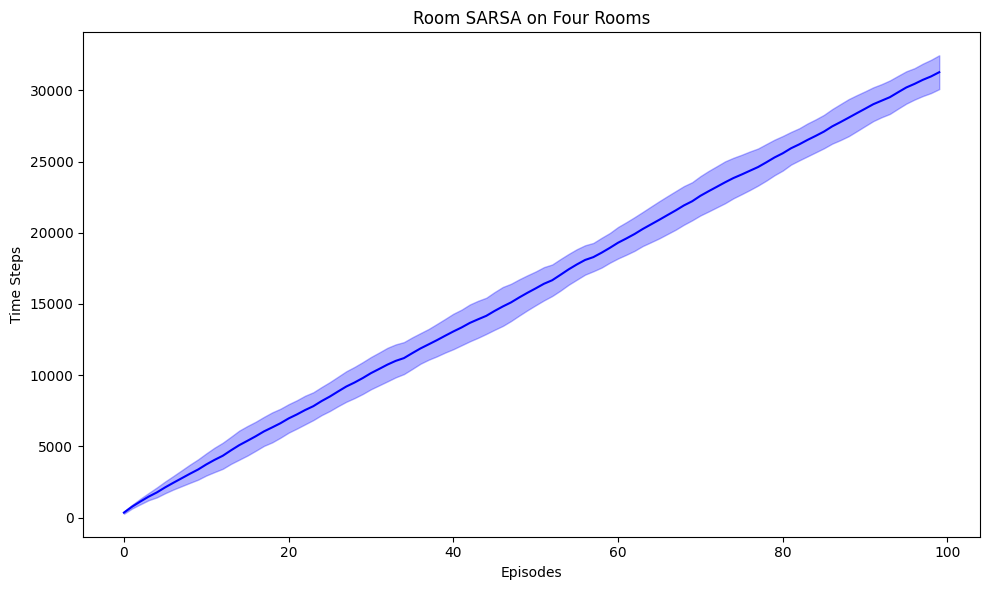

In [25]:
def run_semi_gradient_sarsa():
    epsilon = 0.1
    alpha = 0.5
    gamma = 1.0
    timeout = 459
    trial_num = 10
    
    results_list = []
    for _ in range(trial_num):
        env = FourRooms()
        controller = RoomSARSA(env, gamma, alpha, epsilon)
        steps = controller.run()
        results_list.append(steps)
    
    results_array = np.array(results_list)
    mean_arr = np.nanmean(results_array, axis=0)
    err = 1.96 * np.nanstd(results_array, axis=0) / np.sqrt(trial_num)
    
    plt.figure(figsize=(10, 6))
    plt.plot(range(100), mean_arr, color='b')
    plt.fill_between(range(100), mean_arr - err, mean_arr + err, alpha=0.3, color='b')
    plt.xlabel('Episodes')
    plt.ylabel('Time Steps')
    plt.title('Room SARSA on Four Rooms')
    plt.tight_layout()
    plt.savefig('RoomSARSA.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.show()

run_semi_gradient_sarsa()